# Infraslow Phase vs. U-Sleep Sleep-Stage Probability

Visualizes the relationship between the infraslow (ISFS) phase (see
`demo_plot_and_compared_sigma.ipynb` Section 5.2, whose phase-extraction logic and 8-bin
phase convention this notebook reuses unmodified) and U-Sleep sleep-stage probabilities.

Key figure (Section 4): one subject's 3-s hypnogram, averaged from 1-s U-Sleep
hypnodensity probabilities (never hard-labeled per-second first, then majority-voted --
see Section 3), stacked directly over its ISFS phase curve on a shared real-time x-axis.

Group figure (Section 5-6): the average U-Sleep stage probability across the 8 ISFS phase
bins, computed subject-balanced (each subject's own per-bin mean first, then mean +/- SEM
across subjects -- never pooling raw per-sample probabilities across subjects).

**Assumptions** (see this notebook's own plan, `docs/superpowers/plans/2026-08-20-phase-prob-stages.md`,
for how each was checked on real Sherlock data):
* U-Sleep hypnodensity `.npy` columns are in `Wake, N1, N2, N3, REM` order (matches
  `infraslow.io.hypnodensity`'s existing CSV convention; not independently verifiable from
  the `.npy` files themselves).
* A subject's U-Sleep hypnodensity and `temporal_ISFS`/`envelope` `t_env` share the same
  zero point (recording start) -- checked per subject via a duration-mismatch tolerance,
  not assumed blindly.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yasa

from infraslow.pipeline import io as pio
from infraslow.pipeline import phase as pph
from infraslow.io import usleep_hypnodensity as uh
from infraslow.constants import (
    DEFAULT_HYPNOGRAM_EPOCH_SEC,
    DEFAULT_MIN_BOUT_SEC,
    DEFAULT_USLEEP_ALIGN_TOLERANCE_SEC,
    DEFAULT_USLEEP_HYPNODENSITY_DIR,
    USLEEP_STAGE_ORDER,
)
from infraslow.stat import state_comparison as stc

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
ORANGE, LORANGE = '#d2691e', '#f2c14e'
COLORS = {"N2": (PURPLE, LPURPLE), "N3": (ORANGE, LORANGE)}
STAGE_COLORS = {  # 5-stage group phase-curve figure (Section 6)
    "Wake": "#4c4c4c", "N1": "#8fb8de", "N2": PURPLE, "N3": ORANGE, "REM": "#2a9d8f",
}

DATA_DIR = Path("/scratch/users/chaisaen/processed_data/data")
USLEEP_DIR = DEFAULT_USLEEP_HYPNODENSITY_DIR
CHANNEL = "C3"
STATES = ("N2", "N3")
BAND = "sigma"  # matches EVENT="spindle" in demo_plot_and_compared_sigma.ipynb
HYPNOGRAM_EPOCH_SEC = DEFAULT_HYPNOGRAM_EPOCH_SEC  # 3 s
ALIGN_TOLERANCE_SEC = DEFAULT_USLEEP_ALIGN_TOLERANCE_SEC
# N_SUBJECTS caps how many *usable* subjects (Section 3) feed the group-level phase-locked
# curve (Section 5-6); 139,987 subjects have both a processed_data/C3 tree and a U-Sleep
# hypnodensity file (counted 2026-08-20) -- far more than a demo needs. Raise this for a
# less noisy group estimate.
N_SUBJECTS = 30
REFERENCE_START = pd.Timestamp("2000-01-01")  # arbitrary shared anchor so the hypnogram
# (top) and phase (bottom) subplots in Section 4 can share a real datetime x-axis -- only
# relative alignment matters, not the actual date.

## 2. Per-Subject Loader

Loads and aligns one subject's U-Sleep hypnodensity with its whole-recording ISFS phase
time series, or raises with a short, categorized reason (caught by the cohort-discovery
loop in Section 3). Uses `bouts["all"]` (every consecutive N2/N3 bout, not just
spindle-containing ones -- broader than `demo_plot_and_compared_sigma.ipynb`'s spectral
analysis, which specifically needs spindle-containing bouts) so the phase curve covers as
much of the night's N2/N3 structure as possible, applying the same
`DEFAULT_MIN_BOUT_SEC` defensive length filter `pipeline.pipeline.run_subject_state_channel`
applies.

In [2]:
def load_subject(data_dir: Path, usleep_dir: str, subject_id: str, channel: str,
                  states=STATES, band=BAND, *,
                  align_tolerance_sec: float = ALIGN_TOLERANCE_SEC,
                  min_bout_sec: float = DEFAULT_MIN_BOUT_SEC) -> dict:
    """Load and align one subject's U-Sleep hypnodensity with its infraslow phase time
    series, or raise with a short, categorized reason.

    Returns a dict with keys `t_hyp`, `probs` (1-s hypnodensity), `phase` (this subject's
    whole-recording phase series, pooled across every state in `states` -- N2 and N3
    bouts are time-disjoint by construction, so concatenating and re-sorting is safe), and
    `bouts_by_state` (each state's filtered `(n, 2)` bout array).

    Raises:
        FileNotFoundError: missing U-Sleep hypnodensity, or missing temporal_ISFS/bouts
            artifacts.
        ValueError: alignment mismatch beyond `align_tolerance_sec`, or no usable bouts.
    """
    subject_dir = Path(data_dir) / subject_id
    t_hyp, probs = uh.load_usleep_hypnodensity(subject_id, channel, base_dir=usleep_dir)
    t_env, filtered = pio.load_temporal_isfs(subject_dir, channel, band)

    if abs(t_hyp[-1] - t_env[-1]) > align_tolerance_sec:
        raise ValueError(
            f"alignment mismatch: hypnodensity ends at {t_hyp[-1]:.1f}s, "
            f"temporal_ISFS ends at {t_env[-1]:.1f}s (tolerance {align_tolerance_sec}s)"
        )

    bouts_by_state = {}
    phase_parts = []
    for state in states:
        bouts = pio.load_stage_bouts(subject_dir, channel, state)["all"]
        if bouts.shape[0]:
            durations = bouts[:, 1] - bouts[:, 0]
            bouts = bouts[durations >= min_bout_sec]
        bouts_by_state[state] = bouts
        if bouts.shape[0]:
            series = pph.build_subject_phase_timeseries(t_env, filtered, bouts)
            if series["t"].size:
                phase_parts.append(pd.DataFrame(series).assign(state=state))

    if not phase_parts:
        raise ValueError(f"no usable {'/'.join(states)} bouts (>= {min_bout_sec}s) for this subject")

    phase = pd.concat(phase_parts, ignore_index=True).sort_values("t", kind="stable").reset_index(drop=True)
    return dict(t_hyp=t_hyp, probs=probs, phase=phase, bouts_by_state=bouts_by_state)

## 3. Cohort Discovery

Scans `pio.discover_subjects(DATA_DIR)` (sorted by id), keeping the first `N_SUBJECTS`
subjects `load_subject` succeeds on; every failure is caught and its exact message kept
for the exclusion report below (Section 3.1) rather than crashing the scan.

In [3]:
EXCLUSION_REASONS: dict[str, str] = {}
included: dict[str, dict] = {}
n_scanned = 0
verbose = True

for subject_id in pio.discover_subjects(DATA_DIR):
    if N_SUBJECTS is not None and len(included) >= N_SUBJECTS:
        break
    n_scanned += 1
    try:
        included[subject_id] = load_subject(DATA_DIR, USLEEP_DIR, subject_id, CHANNEL)
        if verbose:
            print(f"[{n_scanned}] {subject_id}: included -- {len(included)}/{N_SUBJECTS or '?'} so far")
    except (FileNotFoundError, ValueError, OSError) as exc:
        EXCLUSION_REASONS[subject_id] = str(exc)
        if verbose:
            print(f"[{n_scanned}] {subject_id}: excluded -- {exc}")

SUBJECT_IDS = list(included)
print(f"\nScanned {n_scanned} subject(s); included {len(SUBJECT_IDS)}, excluded {len(EXCLUSION_REASONS)}.")
assert SUBJECT_IDS, "no usable subjects found -- check DATA_DIR/USLEEP_DIR and CHANNEL"


[1] 317497: excluded -- no usable N2/N3 bouts (>= 200.0s) for this subject
[2] 317947: included -- 1/30 so far
[3] 318517: included -- 2/30 so far
[4] 318562: included -- 3/30 so far
[5] 318619: included -- 4/30 so far
[6] 318658: included -- 5/30 so far
[7] 318661: included -- 6/30 so far
[8] 318667: included -- 7/30 so far
[9] 318668: included -- 8/30 so far
[10] 318679: included -- 9/30 so far
[11] 318709: included -- 10/30 so far
[12] 318728: included -- 11/30 so far
[13] 318730: included -- 12/30 so far
[14] 318732: included -- 13/30 so far
[15] 318743: included -- 14/30 so far
[16] 318763: included -- 15/30 so far
[17] 318764: excluded -- [Errno 2] No such file or directory: '/scratch/users/chaisaen/processed_data/data/318764/C3/temporal_ISFS/sigma.npz'
[18] 318766: included -- 16/30 so far
[19] 318768: included -- 17/30 so far


[20] 318769: included -- 18/30 so far
[21] 318775: excluded -- alignment mismatch: hypnodensity ends at 29879.5s, temporal_ISFS ends at 30015.5s (tolerance 120.0s)
[22] 318778: included -- 19/30 so far
[23] 318783: included -- 20/30 so far
[24] 318819: included -- 21/30 so far
[25] 318825: included -- 22/30 so far
[26] 318826: included -- 23/30 so far
[27] 318843: included -- 24/30 so far
[28] 318848: included -- 25/30 so far
[29] 318858: included -- 26/30 so far
[30] 318860: included -- 27/30 so far
[31] 318865: included -- 28/30 so far
[32] 318868: included -- 29/30 so far
[33] 318871: included -- 30/30 so far

Scanned 33 subject(s); included 30, excluded 3.


### 3.1 Exclusion Report

In [4]:
def _categorize(reason: str) -> str:
    if "No U-Sleep hypnodensity directory" in reason:
        return "missing_usleep_subject_dir"
    if "No U-Sleep hypnodensity file for channel" in reason:
        return "missing_usleep_channel_file"
    if "alignment mismatch" in reason:
        return "alignment_mismatch"
    if "temporal_ISFS" in reason:
        return "missing_temporal_isfs"
    if "bouts.npz" in reason:
        return "missing_bouts_file"
    if "no usable" in reason:
        return "no_usable_bouts"
    return "other"

exclusion_df = pd.DataFrame(
    [{"subject_id": sid, "reason_category": _categorize(reason), "detail": reason}
     for sid, reason in EXCLUSION_REASONS.items()]
)
print(f"Included: {len(SUBJECT_IDS)} / {n_scanned} scanned")
if len(exclusion_df):
    print("\nExcluded, by reason:")
    print(exclusion_df["reason_category"].value_counts().to_string())
else:
    print("No exclusions.")

Included: 30 / 33 scanned

Excluded, by reason:
reason_category
no_usable_bouts          1
missing_temporal_isfs    1
alignment_mismatch       1


## 4. Key Figure -- 3-s Hypnogram vs. ISFS Phase (One Example Subject)

Top: the subject's whole-night 3-s hypnogram (`yasa.Hypnogram`, built by averaging 1-s
hypnodensity probabilities into 3-s windows *before* taking the argmax stage). Bottom: the
same subject's ISFS phase, colored by state (N2/N3) -- only defined inside valid ISFS
cycles (>= `DEFAULT_MIN_BOUT_SEC` N2/N3 bouts), so most of a typical night is a gap. Both
share one real-time x-axis via `REFERENCE_START`, an arbitrary shared anchor (only relative
alignment matters, not the actual date).

Example subject: 317947 (has both N2/N3: True)


/tmp/ipykernel_10456/1125210164.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


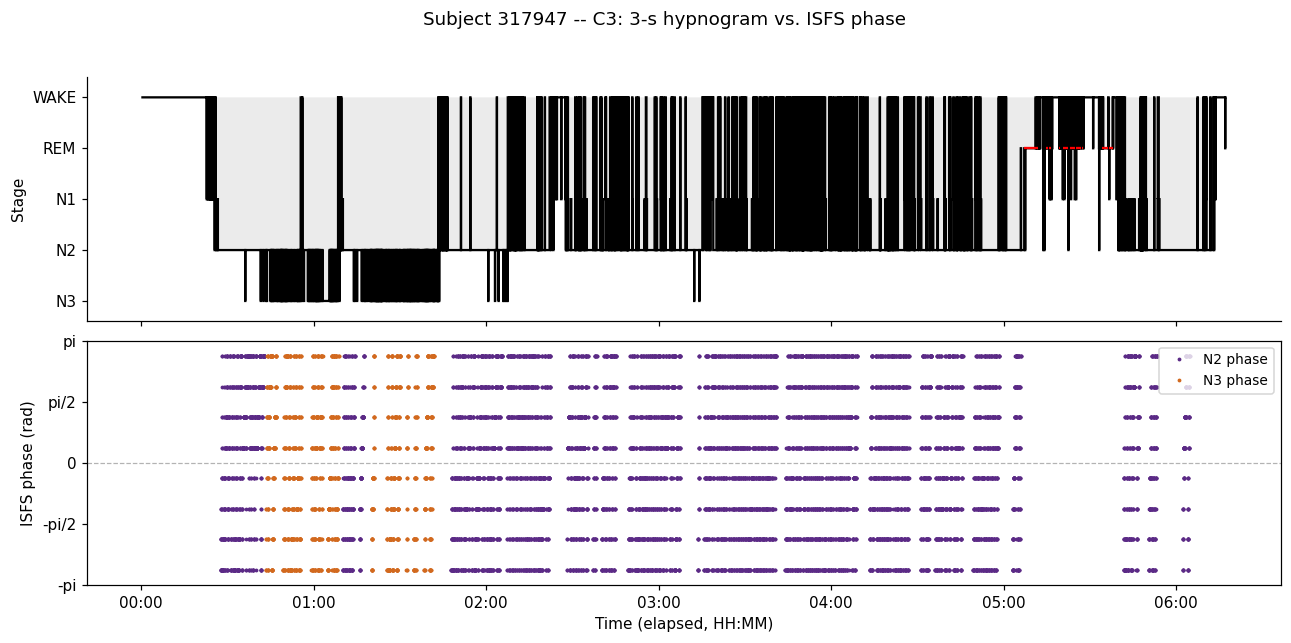

In [5]:
def subject_hypnogram(data: dict, *, epoch_sec: float = HYPNOGRAM_EPOCH_SEC) -> yasa.Hypnogram:
    """3-s yasa.Hypnogram for one loaded subject (Section 2), built by averaging 1-s
    hypnodensity probabilities into `epoch_sec` windows *before* taking the argmax stage."""
    t_epoch, probs_epoch, stage_epoch = uh.hypnodensity_to_epoch_hypnogram(
        data["t_hyp"], data["probs"], epoch_sec=epoch_sec,
    )
    labels = [s.upper() for s in stage_epoch]  # USLEEP_STAGE_ORDER -> YASA's WAKE/N1/N2/N3/REM
    return yasa.Hypnogram(labels, n_stages=5, freq=f"{int(epoch_sec)}s", start=REFERENCE_START)


def plot_hypnogram_and_phase(data: dict, *, states=STATES, colors=COLORS, title: str = "") -> plt.Figure:
    """Section 4's key figure: 3-s hypnogram (top) over the corresponding ISFS phase
    (bottom), sharing one real-time x-axis."""
    hyp = subject_hypnogram(data)

    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=(14, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08},
    )
    hyp.plot_hypnogram(ax=ax_top, fill_color="0.92")
    ax_top.set_xlabel("")
    ax_top.tick_params(labelbottom=False)

    phase = data["phase"]
    for state in states:
        sub = phase[phase["state"] == state]
        if sub.empty:
            continue
        t_dt = REFERENCE_START + pd.to_timedelta(sub["t"].to_numpy(), unit="s")
        dark, _light = colors[state]
        ax_bottom.plot(t_dt, sub["phase_angle"].to_numpy(), ".", color=dark, ms=3, label=f"{state} phase")

    ax_bottom.axhline(0, color="0.7", lw=0.8, ls="--")
    ax_bottom.set(
        ylabel="ISFS phase (rad)",
        yticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        yticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
    )
    ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_bottom.set_xlabel("Time (elapsed, HH:MM)")
    ax_bottom.legend(loc="upper right", frameon=True, fontsize=9)

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig


def _has_both_states(data: dict, states=STATES) -> bool:
    return all(data["bouts_by_state"].get(s, np.empty((0, 2))).shape[0] > 0 for s in states)

example_id = next((sid for sid in SUBJECT_IDS if _has_both_states(included[sid])), SUBJECT_IDS[0])
print(f"Example subject: {example_id} (has both {'/'.join(STATES)}: {_has_both_states(included[example_id])})")

fig = plot_hypnogram_and_phase(
    included[example_id],
    title=f"Subject {example_id} -- {CHANNEL}: 3-s hypnogram vs. ISFS phase",
)

## 5. Group-Level (Subject-Balanced) Average Hypnodensity by ISFS Phase

Per subject: average the hypnodensity probability vector within each of the 8 ISFS phase
bins, across every in-cycle sample pooled over N2+N3 (one `(8, 5)` curve per subject). A
subject missing any of the 8 bins is dropped from this specific group curve (not from the
rest of the notebook). Group level: `stc.mean_sem` (unmodified) across the *subject-level*
curves -- never pooling raw per-sample probabilities across subjects, so every included
subject contributes equally regardless of how many in-cycle samples they have.

In [6]:
def subject_phase_locked_probs(data: dict, *, n_bins: int = 8) -> np.ndarray:
    """This subject's own mean hypnodensity probability vector per ISFS phase bin --
    (n_bins, n_stages), NaN row for any bin with zero in-cycle samples."""
    phase = data["phase"]
    in_cycle = phase["phase_bin"] > 0
    t_in = phase.loc[in_cycle, "t"].to_numpy()
    bins_in = phase.loc[in_cycle, "phase_bin"].to_numpy()
    probs_at = uh.hypnodensity_probs_at_times(t_in, data["t_hyp"], data["probs"])

    out = np.full((n_bins, len(USLEEP_STAGE_ORDER)), np.nan)
    for b in range(1, n_bins + 1):
        mask = bins_in == b
        if mask.any():
            out[b - 1] = probs_at[mask].mean(axis=0)
    return out


subject_curves = {}
for sid in SUBJECT_IDS:
    curve = subject_phase_locked_probs(included[sid])
    if not np.isnan(curve).any():
        subject_curves[sid] = curve

n_complete = len(subject_curves)
print(f"{n_complete}/{len(SUBJECT_IDS)} included subjects have samples in all 8 ISFS phase bins "
      f"(pooled across {'/'.join(STATES)}) -- these feed the group-level curve below.")
assert n_complete > 0, "no subject has complete 8-bin phase coverage -- try raising N_SUBJECTS"

group_stack = np.stack(list(subject_curves.values()))  # (n_complete, 8, n_stages)
group_mean, group_sem = stc.mean_sem(group_stack, axis=0)  # each (8, n_stages)
bin_centers = pph.bin_center_angle(np.arange(1, 9))

30/30 included subjects have samples in all 8 ISFS phase bins (pooled across N2/N3) -- these feed the group-level curve below.


#### Figure: average hypnodensity probability across ISFS phase

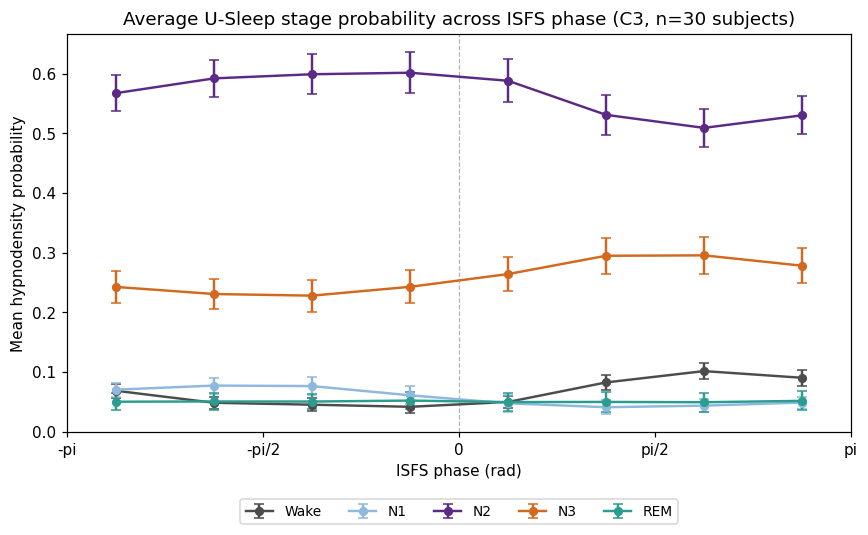

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for k, stage in enumerate(USLEEP_STAGE_ORDER):
    ax.errorbar(bin_centers, group_mean[:, k], yerr=group_sem[:, k], color=STAGE_COLORS[stage],
                marker="o", ms=5, capsize=3, lw=1.6, label=stage)
ax.axvline(0, color="0.7", lw=0.8, ls="--")
ax.set(xlabel="ISFS phase (rad)", ylabel="Mean hypnodensity probability",
       xticks=[-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
       xticklabels=["-pi", "-pi/2", "0", "pi/2", "pi"],
       title=f"Average U-Sleep stage probability across ISFS phase ({CHANNEL}, n={n_complete} subjects)")
ax.legend(frameon=True, fontsize=9, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
fig.tight_layout()

## 6. Summary

In [8]:
print("=== Subject inclusion summary ===")
print(f"Scanned:  {n_scanned}")
print(f"Included: {len(SUBJECT_IDS)}")
print(f"Excluded: {len(EXCLUSION_REASONS)}")
if len(exclusion_df):
    print("\nExclusion reasons:")
    for reason, count in exclusion_df["reason_category"].value_counts().items():
        print(f"  {reason}: {count}")
print(f"\nSubjects contributing to the group phase-locked curve "
      f"(complete 8-bin coverage pooled across {'/'.join(STATES)}): {n_complete}/{len(SUBJECT_IDS)}")
print(f"\nExample subject shown in the key figure (Section 4): {example_id}")

=== Subject inclusion summary ===
Scanned:  33
Included: 30
Excluded: 3

Exclusion reasons:
  no_usable_bouts: 1
  missing_temporal_isfs: 1
  alignment_mismatch: 1

Subjects contributing to the group phase-locked curve (complete 8-bin coverage pooled across N2/N3): 30/30

Example subject shown in the key figure (Section 4): 317947
